In [ ]:
# explore different variants of convulation and functions. implement and compare different CNN architectures using various convuolution and pooling techniques. Experiment with efficient convolution algorithm and random features

In [3]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
import numpy as np
import matplotlib.pyplot as plt

In [4]:
(X_train, y_train), (X_test, y_test) = keras.datasets.cifar10.load_data()

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 394s 2us/step


In [5]:
X_train, X_test = X_train / 255.0, X_test / 255.0

In [6]:
def standard_cnn():

    model = models.Sequential([

        layers.Conv2D(
            32,
            (3,3),
            activation='relu',
            padding='same',
            input_shape=(32,32,3)
        ),

        layers.MaxPooling2D((2,2)),

        layers.Conv2D(
            64,
            (3,3),
            activation='relu',
            padding='same'
        ),

        layers.GlobalAveragePooling2D(),

        layers.Dense(64, activation='relu'),

        layers.Dense(10, activation='softmax')

    ])

    return model

In [7]:
def depthwise_separable_cnn():

    model = models.Sequential([

        layers.SeparableConv2D(
            32,
            (5,3),
            activation='relu',
            padding='same',
            input_shape=(32,32,3)
        ),

        layers.MaxPooling2D((2,2)),

        layers.SeparableConv2D(
            64,
            (3,3),
            activation='relu',
            padding='same'
        ),

        layers.GlobalAveragePooling2D(),

        layers.Dense(64, activation='relu'),

        layers.Dense(10, activation='softmax')

    ])

    return model

In [8]:
def dilated_cnn():

    model = models.Sequential([

        layers.Conv2D(
            32,
            (3,3),
            activation='relu',
            padding='same',
            dilation_rate=2,
            input_shape=(32,32,3)
        ),

        layers.MaxPooling2D((2,2)),

        layers.Conv2D(
            64,
            (3,3),
            activation='relu',
            padding='same',
            dilation_rate=2
        ),

        layers.MaxPooling2D((2,2)),

        layers.Conv2D(
            128,
            (3,3),
            activation='relu',
            padding='same',
            dilation_rate=2
        ),

        layers.GlobalAveragePooling2D(),

        layers.Dense(64, activation='relu'),

        layers.Dense(10, activation='softmax')

    ])

    return model

In [9]:
def train_and_evaluate(model, name):

    model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    print(f"\nTraining {name} model...")

    history = model.fit(
        X_train,
        y_train,
        epochs=10,
        batch_size=64,
        validation_data=(X_test, y_test)
    )

    test_loss, test_acc = model.evaluate(
        X_test,
        y_test,
        verbose=2
    )

    print(f"{name} Test Accuracy: {test_acc:.4f}")

    return history

In [10]:
model_dict = {

    'Standard CNN': standard_cnn(),

    'DepthWise Separable CNN': depthwise_separable_cnn(),

    'Dilated CNN': dilated_cnn()

}

histories = {}

for name, model in model_dict.items():

    histories[name] = train_and_evaluate(model, name)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_separable_conv.py:104: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(



Training Standard CNN model...
Epoch 1/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 73s 92ms/step - accuracy: 0.2626 - loss: 1.9384 - val_accuracy: 0.3238 - val_loss: 1.7490
Epoch 2/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 67s 86ms/step - accuracy: 0.3501 - loss: 1.7155 - val_accuracy: 0.3775 - val_loss: 1.6564
Epoch 3/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 82s 86ms/step - accuracy: 0.3855 - loss: 1.6421 - val_accuracy: 0.3905 - val_loss: 1.6617
Epoch 4/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 86s 91ms/step - accuracy: 0.4125 - loss: 1.5847 - val_accuracy: 0.4364 - val_loss: 1.5318
Epoch 5/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 70s 90ms/step - accuracy: 0.4414 - loss: 1.5257 - val_accuracy: 0.4445 - val_loss: 1.5156
Epoch 6/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 81s 89ms/step - accuracy: 0.4609 - loss: 1.4793 - val_accuracy: 0.4667 - val_loss: 1.4477
Epoch 7/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 68s 87ms/step - accuracy: 0.4810 - loss: 1.4299 - val_accuracy: 0.4859 - val_loss: 1.3990
Epoch 8/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 83s 88ms/step - ac

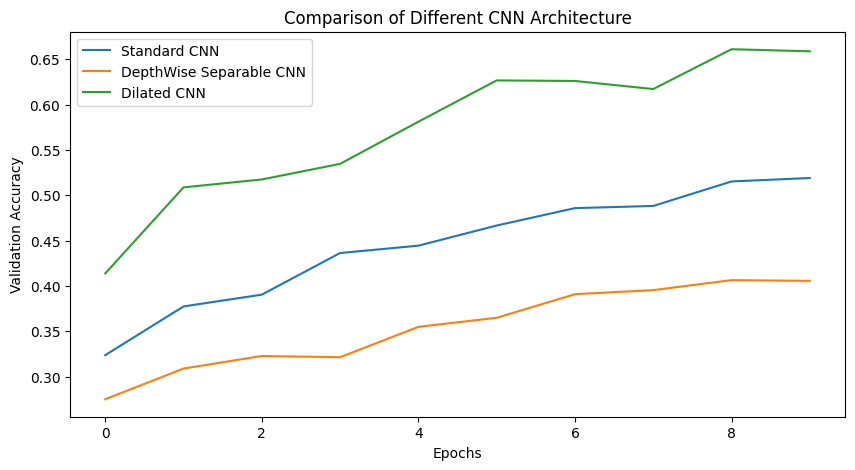

In [11]:
plt.figure(figsize=(10,5))

for name, history in histories.items():

    plt.plot(
        history.history['val_accuracy'],
        label=name
    )

plt.xlabel("Epochs")

plt.ylabel("Validation Accuracy")

plt.legend()

plt.title("Comparison of Different CNN Architecture")

plt.show()